c:\Users\shrin\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\shrin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


📏 Silhouette Score (UMAP): 0.3985


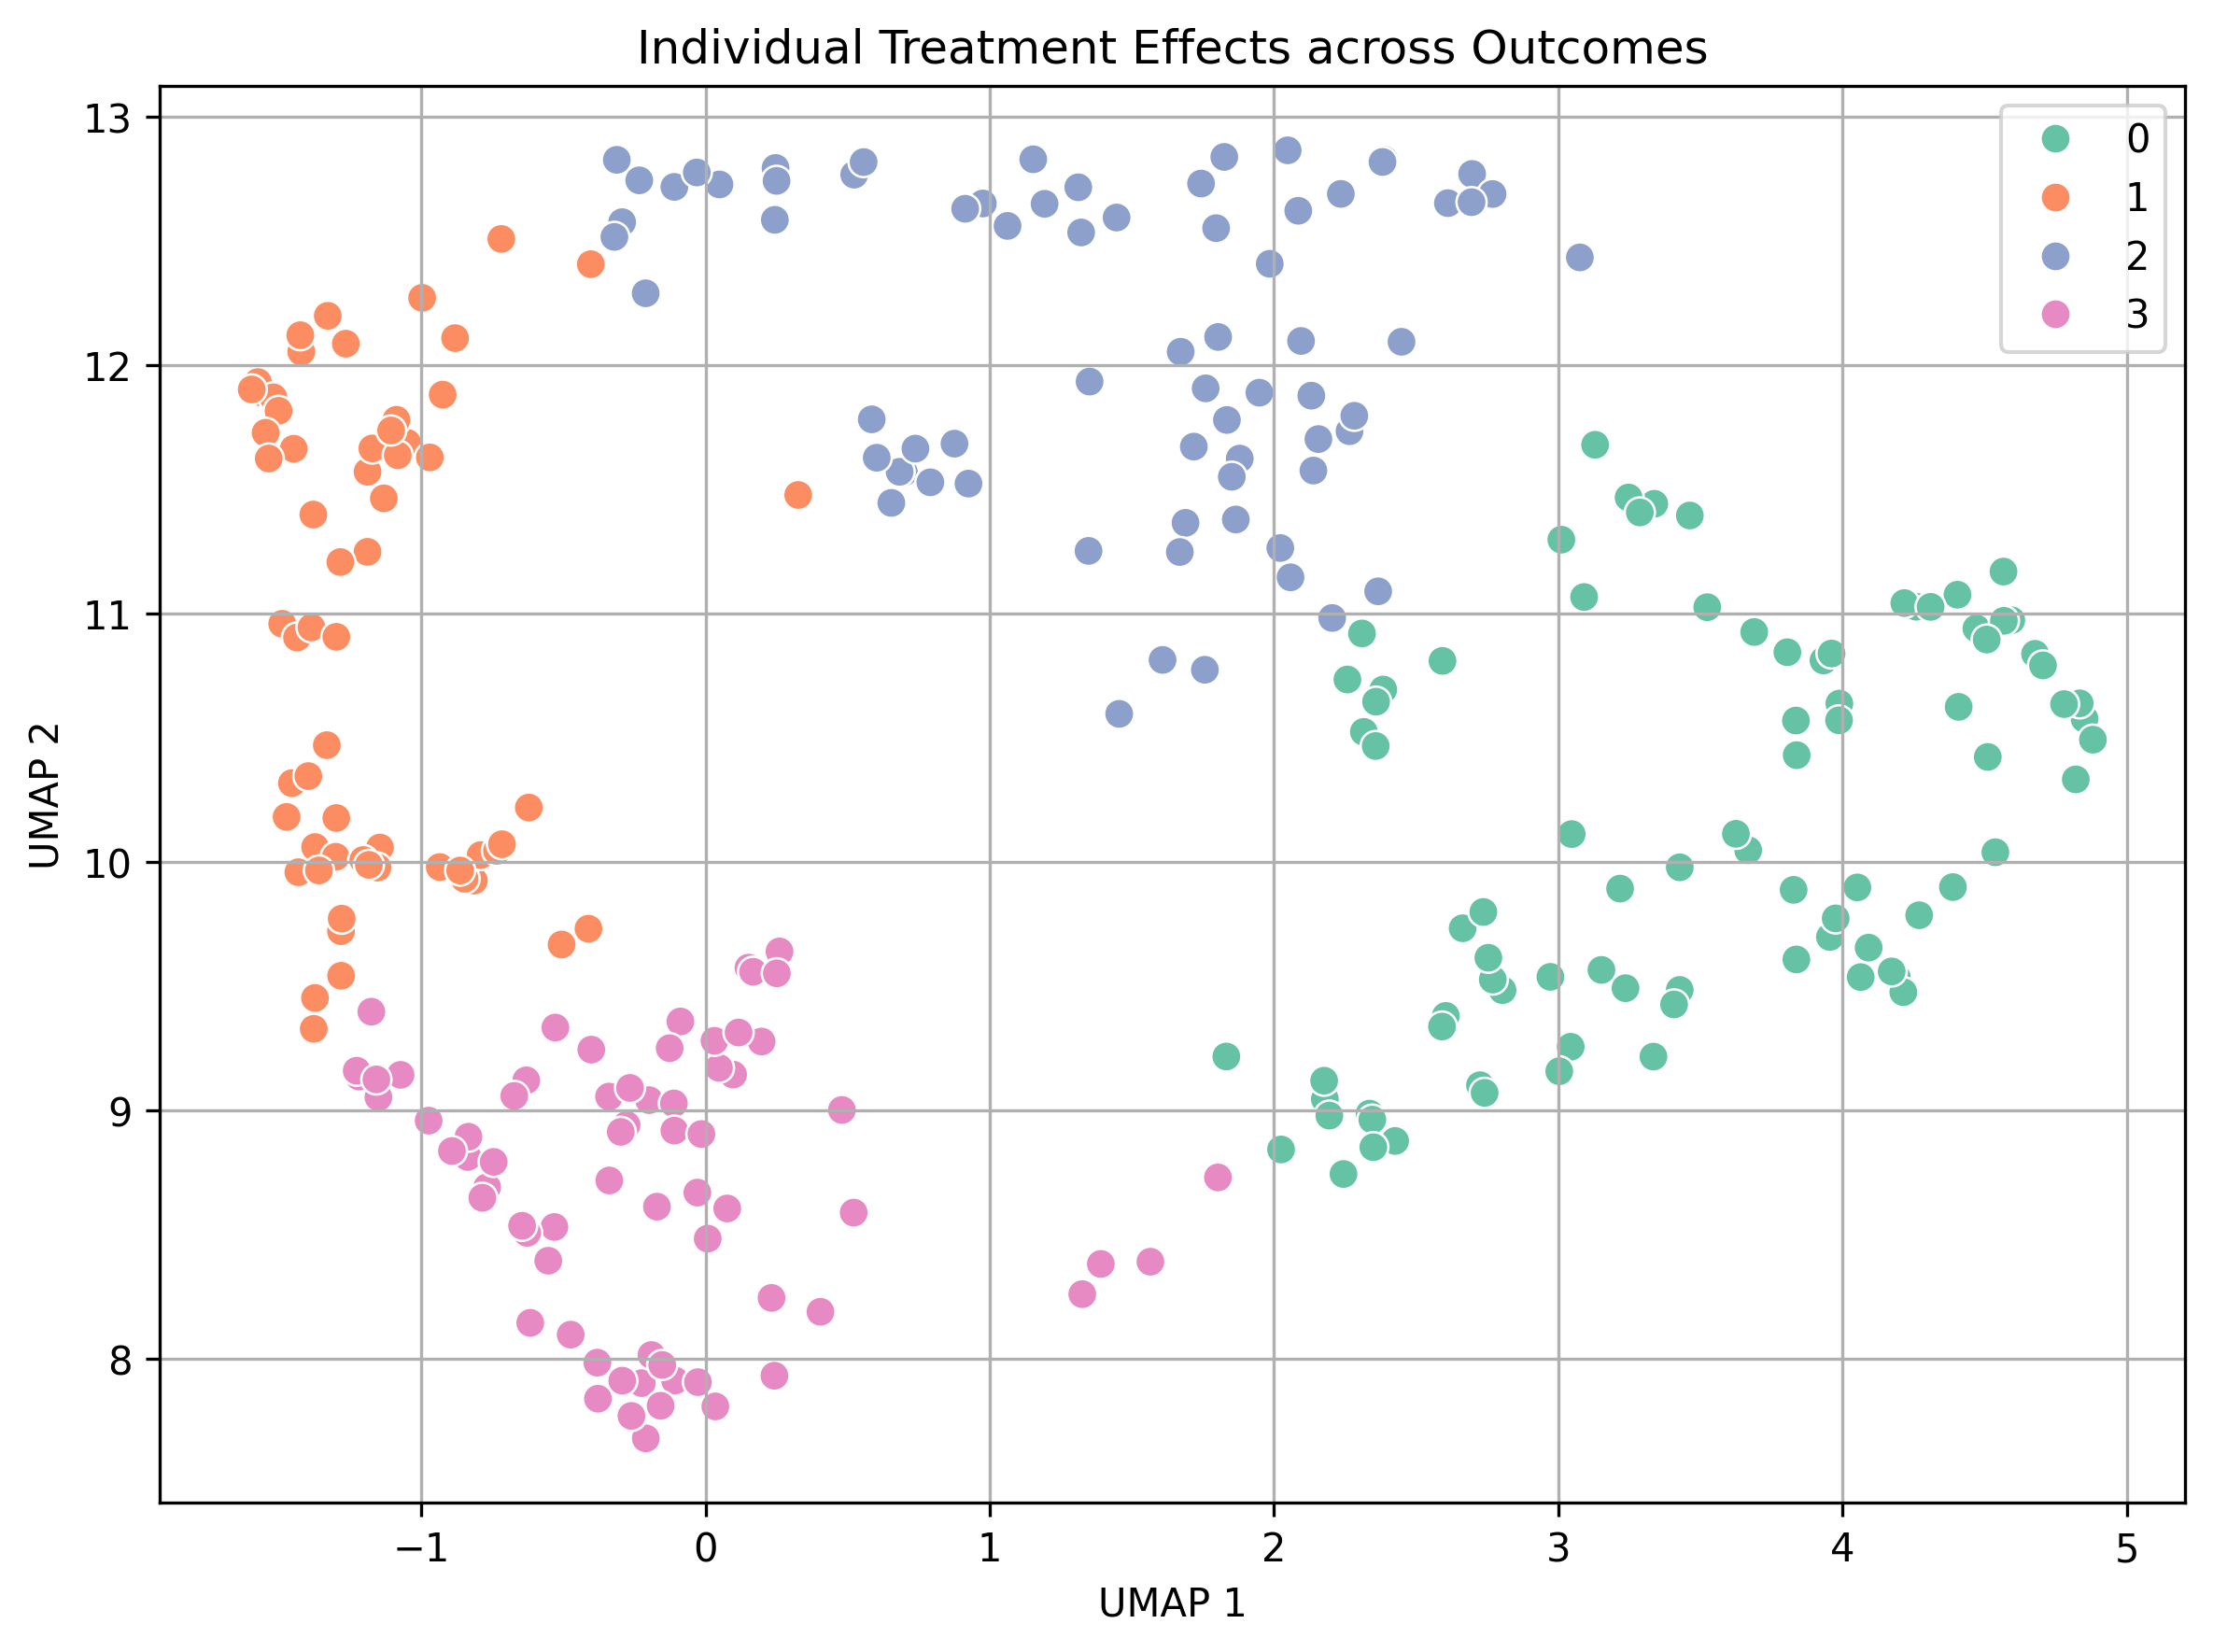

In [1]:
from modules.cluster import generate_cate_matrix, umap_cluster_cates, visualize_clusters, visualize_clusters_3d_plotly, plot_cate_tradeoff
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from modules.preprocess import load_and_clean_data, prepare_variables



# Step 1: prepare baseline
df = load_and_clean_data("ed.csv", ed_daily_path="ed_daily.csv")
X, Y, T, feature_names = prepare_variables(df, outcome_col='mrs_binary')  # any outcome will do, X is same

# Step 2: define CATE sources
cate_file_dict = {
    "mrs_binary": "cate_results/cate_results_mrs_binary.csv",
    "infarct_dch": "cate_results/cate_results_infarct_dch.csv",
    "vs_clin": "cate_results/cate_results_vs_clin.csv",
    "infection_dch": "cate_results/cate_results_infection_dch.csv",
    "gos_binary": "cate_results/cate_results_gos_binary.csv",
    "shunt_180": "cate_results/cate_results_shunt_180.csv",
}

# Step 3: build matrix
cate_matrix = generate_cate_matrix(X, cate_file_dict)


from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer

import matplotlib.pyplot as plt
import seaborn as sns



# Step 4: UMAP-based cluster
X_umap, clusters, reducer, kmeans = umap_cluster_cates(cate_matrix, n_clusters=4)
# Step 5: Visualize
visualize_clusters(X_umap, clusters, method="UMAP")


In [3]:
df.columns

Index(['no', 'random', 'age', 'sex', 'height', 'weight', 'mrs_adm', 'gcs',
       'hh', 'sedation_adm', 'aneurysm_no', 'aneurysm_trt', 'infarct_trt',
       'hemorrhage_trt', 'infarct_dch', 'rehab_dch', 'barthel_dch',
       'rehab_barthel_dch', 'mrs_dch', 'rehab_score_180', 'barthel_180',
       'rehab_barthel_180', 'mrs_180', 'gos8_180', 'aneurysm_circulation',
       'aneurysm_location', 'aneurysm_size', 'hemorrh_before', 'paresis_adm',
       'aphasia_adm', 'loc_dch', 'infection_dch', 'gos8_dch',
       'dch_imag_modality', 'shunt_dch', 'shunt_180', 'nimodipine', 'statin',
       'mg', 'vs_clin', 'vs_angio_amount', 'vs_angio_trt_endo', 'query_180',
       'evd_mean', 'ld_mean', 'evd_total', 'ld_total', 'csf_total', 'tcd_max',
       'center_size', 'wfns', 'ct_ivh', 'ct_ich', 'ct_origfisher',
       'ct_modfisher', 'days_sah_trt', 'days_sah_trt_ct', 'days_sah_icu',
       'days_trt_icu', 'days_sah_ld', 'days_angio_vs', 'days_sah_dch',
       'days_sah_dch_imaging', 'days_sah_death',

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, f_oneway
import warnings
warnings.filterwarnings('ignore')

# Attach cluster labels to dataframe
df['cluster'] = clusters

# List of continuous variables for mean ± SD comparisons
continuous_vars = ['age', 'bmi', 'icp_high_mean']  # You can add more

# Categorical (binary) variables for frequency comparison
binary_vars = ['ct_ivh', 'ct_ich', 'paresis_adm', 'aphasia_adm', 'nimodipine', 'statin', 'mg']

# Initialize summary dict
summary = {}

print("📊 Mean ± SD and ANOVA P-Values:\n")
for var in continuous_vars:
    print(f"\n--- {var.upper()} ---")
    for c in sorted(df['cluster'].unique()):
        mean = df[df['cluster'] == c][var].mean()
        std = df[df['cluster'] == c][var].std()
        print(f"Cluster {c}: {mean:.2f} ± {std:.2f}")
    
    # ANOVA test across clusters
    groups = [df[df['cluster'] == c][var].dropna() for c in sorted(df['cluster'].unique())]
    fstat, pval = f_oneway(*groups)
    print(f"P-value: {pval:.4f}")

print("\n📊 Binary Variable Frequencies and Chi-Square:\n")
from scipy.stats import chi2_contingency

for var in binary_vars:
    print(f"\n--- {var.upper()} ---")
    freq_table = pd.crosstab(df['cluster'], df[var])
    print(freq_table)
    
    if freq_table.shape[1] == 2:
        chi2, p, _, _ = chi2_contingency(freq_table)
        print(f"P-value: {p:.4f}")
    else:
        print("⚠️ Not binary, skipping chi-square test.")


📊 Mean ± SD and ANOVA P-Values:


--- AGE ---
Cluster 0: 53.14 ± 12.95
Cluster 1: 54.59 ± 11.31
Cluster 2: 52.21 ± 11.66
Cluster 3: 62.58 ± 10.81
P-value: 0.0000

--- BMI ---
Cluster 0: 44.05 ± 23.61
Cluster 1: 25.82 ± 9.88
Cluster 2: 36.15 ± 20.85
Cluster 3: 26.34 ± 4.82
P-value: 0.0000

--- ICP_HIGH_MEAN ---
Cluster 0: 14.11 ± 5.30
Cluster 1: 22.58 ± 6.48
Cluster 2: 18.81 ± 5.64
Cluster 3: 16.13 ± 5.90
P-value: 0.0000

📊 Binary Variable Frequencies and Chi-Square:


--- CT_IVH ---
ct_ivh    0   1
cluster        
0        42  44
1        17  44
2        41  30
3        12  57
P-value: 0.0000

--- CT_ICH ---
ct_ich    0   1
cluster        
0        64  22
1        34  27
2        54  17
3        29  40
P-value: 0.0000

--- PARESIS_ADM ---
paresis_adm   0   1
cluster            
0            63  23
1            45  16
2            56  15
3            36  33
P-value: 0.0031

--- APHASIA_ADM ---
aphasia_adm   0   1
cluster            
0            59  27
1            44  17
2            5

In [2]:
visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=None , method="UMAP")

In [8]:
fig = visualize_clusters_3d_plotly(X_umap, clusters, kmeans_model=kmeans, method="UMAP")

# 🧹 Strip unsafe template
fig.layout.template = "none"

# ✅ Save clean figure
import plotly.io as pio
pio.write_json(fig, "clusters/umap_plot.json", pretty=True)


In [4]:
from joblib import dump



# Save UMAP + KMeans
dump(X_umap, "clusters/umap_embedding.joblib")
dump(clusters, "clusters/umap_clusters.joblib")
dump(reducer, "clusters/umap_model.joblib")         
dump(kmeans, "clusters/kmeans_model.joblib")       


['clusters/kmeans_model.joblib']

In [5]:
import pandas as pd
df_clustered = pd.DataFrame(X, columns=feature_names)
df_clustered['cluster'] = clusters

# Compare means across clusters
cluster_summary = df_clustered.groupby('cluster').mean()
print(cluster_summary)


               age        hh    ct_ivh    ct_ich       sex  aneurysm_trt  \
cluster                                                                    
0        52.887640  2.685393  0.505618  0.258427  0.359551      0.573034   
1        60.276923  3.446154  0.784615  0.584615  0.307692      0.323077   
2        62.530612  3.693878  0.816327  0.469388  0.265306      0.551020   
3        50.428571  2.452381  0.464286  0.261905  0.297619      0.571429   

         aneurysm_circulation   mrs_adm  aneurysm_size  aneurysm_no  ...  \
cluster                                                              ...   
0                    0.786517  0.955056       7.827151     1.393258  ...   
1                    0.923077  0.907692       6.912308     1.584615  ...   
2                    0.755102  0.877551       5.963540     1.326531  ...   
3                    0.904762  0.976190       7.086143     1.297619  ...   

         ct_modfisher        bmi  rr_map_mean  rr_syst_mean  rr_dia_mean  \
cluster   

In [6]:
cate_df = pd.DataFrame(cate_matrix, columns=list(cate_file_dict.keys()))
cate_df['cluster'] = clusters

# Mean CATEs per cluster
print(cate_df.groupby('cluster').mean())


         mrs_binary  infarct_dch   vs_clin  infection_dch  gos_binary  \
cluster                                                                 
0          0.051924     0.060904 -0.079670       0.072482    0.060904   
1         -0.005743    -0.024777 -0.091807       0.022491   -0.024777   
2         -0.008246     0.049234 -0.121631      -0.007300    0.049234   
3          0.041127     0.081531 -0.065735       0.052428    0.081531   

         shunt_180  
cluster             
0        -0.024432  
1         0.076736  
2         0.054180  
3         0.105314  


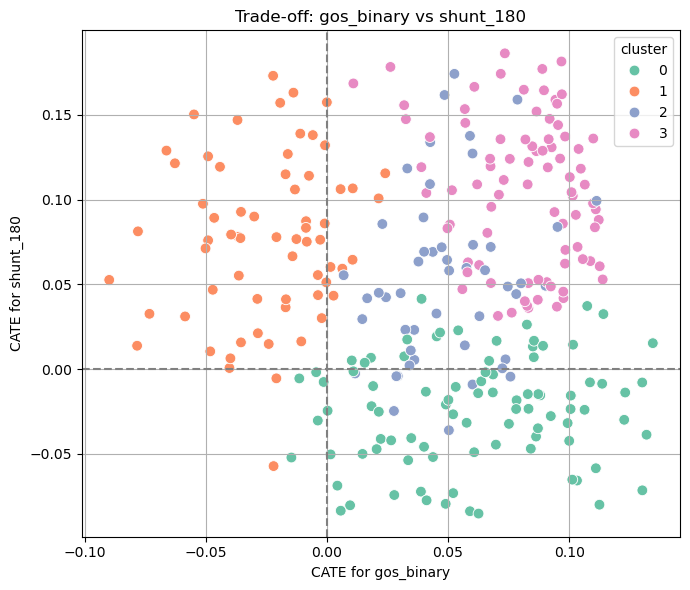

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cate_df = pd.DataFrame(cate_matrix, columns=cate_file_dict.keys())
cate_df['cluster'] = clusters

plot_cate_tradeoff(cate_df, "gos_binary", "shunt_180", clusters=cate_df['cluster'])
